In [2]:
import pandas as pd
from pathlib import Path

data_path = Path("../data/raw")

list(data_path.iterdir())

[WindowsPath('../data/raw/ElectroTech Forecasting Data.csv')]

In [3]:
import pandas as pd

df = pd.read_csv("../data/raw/ElectroTech Forecasting Data.csv")
df.head()

,Product_ID,Category,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume
0,1103,Laptop,105.32,2009-01-01,Winter,-1.859160,0.546694,84.680465,Spec_C,Long-Battery-Life,49
1,1436,Tablet,145.55,2009-01-01,Winter,-0.345587,0.940428,42.919288,Spec_C,Lightweight,69
2,1271,Smartphone,97.82,2009-01-01,Winter,-0.384738,0.751155,55.191268,Spec_B,Lightweight,50
3,1107,Laptop,64.00,2009-01-01,Winter,0.716763,0.125939,88.746454,Spec_B,High-Resolution,28
4,1072,Tablet,67.83,2009-01-01,Winter,-0.242074,-0.412932,67.947536,Spec_A,Long-Battery-Life,81


In [4]:
df.shape

(136193, 11)

In [5]:
df.columns

Index(['Product_ID', 'Category', 'Price', 'Date', 'Season',
       'Market_Trend_Index', 'Competitor_Activity_Score',
       'Consumer_Confidence_Index', 'Product_Specification_1',
       'Product_Specification_2', 'Sales_Volume'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 136193 entries, 0 to 136192
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Product_ID                 136193 non-null  int64  
 1   Category                   136193 non-null  str    
 2   Price                      136193 non-null  float64
 3   Date                       136193 non-null  str    
 4   Season                     136193 non-null  str    
 5   Market_Trend_Index         136193 non-null  float64
 6   Competitor_Activity_Score  136193 non-null  float64
 7   Consumer_Confidence_Index  136193 non-null  float64
 8   Product_Specification_1    136193 non-null  str    
 9   Product_Specification_2    136193 non-null  str    
 10  Sales_Volume               136193 non-null  int64  
dtypes: float64(4), int64(2), str(5)
memory usage: 17.2 MB


In [7]:
df.head()

,Product_ID,Category,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume
0,1103,Laptop,105.32,2009-01-01,Winter,-1.859160,0.546694,84.680465,Spec_C,Long-Battery-Life,49
1,1436,Tablet,145.55,2009-01-01,Winter,-0.345587,0.940428,42.919288,Spec_C,Lightweight,69
2,1271,Smartphone,97.82,2009-01-01,Winter,-0.384738,0.751155,55.191268,Spec_B,Lightweight,50
3,1107,Laptop,64.00,2009-01-01,Winter,0.716763,0.125939,88.746454,Spec_B,High-Resolution,28
4,1072,Tablet,67.83,2009-01-01,Winter,-0.242074,-0.412932,67.947536,Spec_A,Long-Battery-Life,81



---

# 🧠 3. Markdown: Dataset Overview

```markdown
## 📊 Dataset Overview

The dataset contains **136,193 rows and 11 columns**, providing a rich set of features for analysis.

### Column Categories

#### 🔢 Numerical Features
- Price
- Market_Trend_Index
- Competitor_Activity_Score
- Consumer_Confidence_Index
- Sales_Volume (Target)

#### 🏷️ Categorical Features
- Category
- Season
- Product_Specification_1
- Product_Specification_2

#### 🕒 Time Feature
- Date

#### 🆔 Identifier
- Product_ID (used for identification, not modeling)

### Key Observations

- No missing values detected across columns
- Dataset includes both **internal (price, product)** and **external (market, competitor)** factors
- Suitable for both **time series** and **machine learning models**

## 🎯 Target Variable Selection

The target variable for this project is **`Sales_Volume`**.

### Why Sales_Volume?

- It directly represents the **quantity of products sold**, which aligns with the business goal of demand forecasting.
- Forecasting sales volume helps in:
  - **Inventory management** (avoiding stockouts and overstocking)
  - **Revenue optimization**
  - **Strategic planning**
- It is a **time-dependent variable**, making it suitable for time series forecasting.
- All other variables (e.g., price, market trends, competitor activity) act as **influencing factors (features)**.

### Business Impact

By accurately predicting `Sales_Volume`, the company can:
- Ensure product availability during peak demand
- Reduce storage costs
- Improve customer satisfaction

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

## 📅 Date Column Transformation

The `Date` column was originally stored as a string (`object` type), which is not suitable for time series analysis.

### Why convert Date to datetime?

- Enables **time-based operations** such as:
  - Sorting data chronologically
  - Extracting features like month, year, and day
- Required for **time series models** (e.g., ARIMA)
- Helps in identifying:
  - Trends
  - Seasonality
  - Temporal patterns

### Transformation Applied

```python
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df.dtypes

Product_ID                            int64
Category                                str
Price                               float64
Date                         datetime64[us]
Season                                  str
Market_Trend_Index                  float64
Competitor_Activity_Score           float64
Consumer_Confidence_Index           float64
Product_Specification_1                 str
Product_Specification_2                 str
Sales_Volume                          int64
dtype: object

In [10]:
df['Date'].min(), df['Date'].max()

(Timestamp('2009-01-01 00:00:00'), Timestamp('2020-12-30 00:00:00'))

In [11]:
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 136193 entries, 0 to 136192
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Product_ID                 136193 non-null  int64         
 1   Category                   136193 non-null  str           
 2   Price                      136193 non-null  float64       
 3   Date                       136193 non-null  datetime64[us]
 4   Season                     136193 non-null  str           
 5   Market_Trend_Index         136193 non-null  float64       
 6   Competitor_Activity_Score  136193 non-null  float64       
 7   Consumer_Confidence_Index  136193 non-null  float64       
 8   Product_Specification_1    136193 non-null  str           
 9   Product_Specification_2    136193 non-null  str           
 10  Sales_Volume               136193 non-null  int64         
dtypes: datetime64[us](1), float64(4), int64(2), str(4)
memory usage

,Product_ID,Category,Price,Date,Season,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Product_Specification_1,Product_Specification_2,Sales_Volume
0,1103,Laptop,105.32,2009-01-01,Winter,-1.859160,0.546694,84.680465,Spec_C,Long-Battery-Life,49
1,1436,Tablet,145.55,2009-01-01,Winter,-0.345587,0.940428,42.919288,Spec_C,Lightweight,69
2,1271,Smartphone,97.82,2009-01-01,Winter,-0.384738,0.751155,55.191268,Spec_B,Lightweight,50
3,1107,Laptop,64.00,2009-01-01,Winter,0.716763,0.125939,88.746454,Spec_B,High-Resolution,28
4,1072,Tablet,67.83,2009-01-01,Winter,-0.242074,-0.412932,67.947536,Spec_A,Long-Battery-Life,81


In [12]:
df.isnull().sum()
df.duplicated().sum()


np.int64(0)

In [13]:
df.describe()

,Product_ID,Price,Date,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index,Sales_Volume
count,136193.000000,136193.000000,136193,136193.000000,136193.000000,136193.000000,136193.000000
mean,1347.703384,106.812513,2014-12-22 05:17:20.062264,-0.000277,-0.000656,70.013109,122.305140
min,1001.000000,40.510000,2009-01-01 00:00:00,-4.067055,-4.181590,40.044830,6.000000
25%,1174.000000,75.560000,2011-12-29 00:00:00,-0.683015,-0.676466,57.521063,81.000000
50%,1348.000000,104.710000,2014-12-19 00:00:00,0.001093,0.000555,70.022715,119.000000
75%,1522.000000,138.310000,2017-11-27 00:00:00,0.680506,0.674953,82.569582,161.000000
max,1694.000000,181.800000,2020-12-30 00:00:00,4.728391,4.661979,99.926291,306.000000
std,200.341518,36.419229,NaN,1.009105,1.001551,14.733722,54.320849


In [14]:
df.dtypes

Product_ID                            int64
Category                                str
Price                               float64
Date                         datetime64[us]
Season                                  str
Market_Trend_Index                  float64
Competitor_Activity_Score           float64
Consumer_Confidence_Index           float64
Product_Specification_1                 str
Product_Specification_2                 str
Sales_Volume                          int64
dtype: object



```markdown
## 🧠 Analytical Approach

This project follows a structured data science workflow:

1. Data Understanding
2. Data Cleaning and Preprocessing
3. Feature Engineering
4. Exploratory Data Analysis (EDA)
5. Model Building and Evaluation
6. Deployment and Visualization

This approach ensures both **technical accuracy** and **business relevance**.

In [15]:
df['Date'].min(), df['Date'].max()

(Timestamp('2009-01-01 00:00:00'), Timestamp('2020-12-30 00:00:00'))

## 📅 Time Range of Data

Understanding the time span of the dataset is important for identifying trends and seasonality.

This helps determine:
- Whether the data covers multiple years
- Whether seasonal patterns can be analyzed

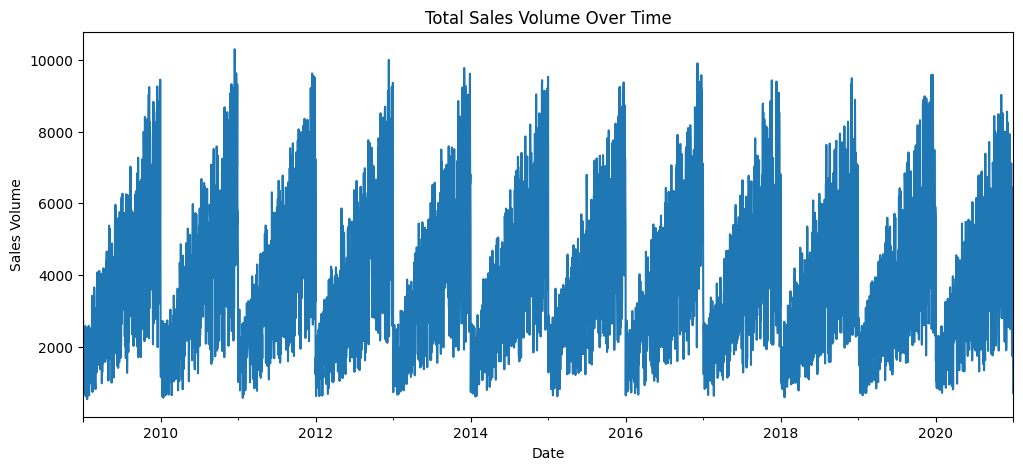

In [16]:
import matplotlib.pyplot as plt

df.groupby('Date')['Sales_Volume'].sum().plot(figsize=(12,5))
plt.title("Total Sales Volume Over Time")
plt.ylabel("Sales Volume")
plt.xlabel("Date")
plt.show()

## 📈 Sales Trend Analysis

The sales volume over time shows a clear **repeating pattern**, indicating strong seasonality in the dataset.

### Key Observations:
- Sales follow a **cyclical pattern**, repeating across years
- There are consistent **peaks and troughs**, suggesting predictable demand periods
- No strong long-term upward or downward trend is observed, indicating relatively stable overall demand

### Insight:
This confirms that **seasonality is a major driver of sales**, making the dataset highly suitable for time series forecasting models such as ARIMA or Exponential Smoothing.

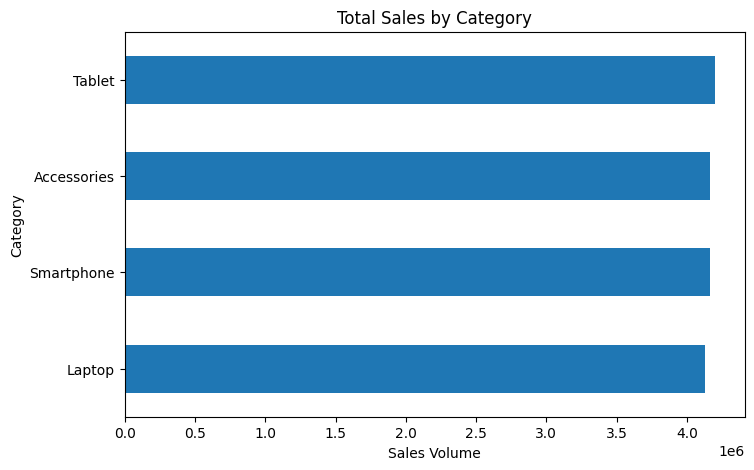

In [17]:
df.groupby('Category')['Sales_Volume'].sum().sort_values().plot(kind='barh', figsize=(8,5))
plt.title("Total Sales by Category")
plt.xlabel("Sales Volume")
plt.show()

## 🏷️ Sales Distribution by Category

The total sales across product categories (Laptop, Smartphone, Tablet, Accessories) appear relatively balanced.

### Key Observations:
- No single category overwhelmingly dominates sales
- All categories contribute significantly to overall revenue
- Slight variations exist, but differences are not extreme

### Insight:
This suggests that forecasting should consider **category-level patterns**, as each category contributes meaningfully to total demand.

It also indicates a **diversified product portfolio**, reducing reliance on a single product type.

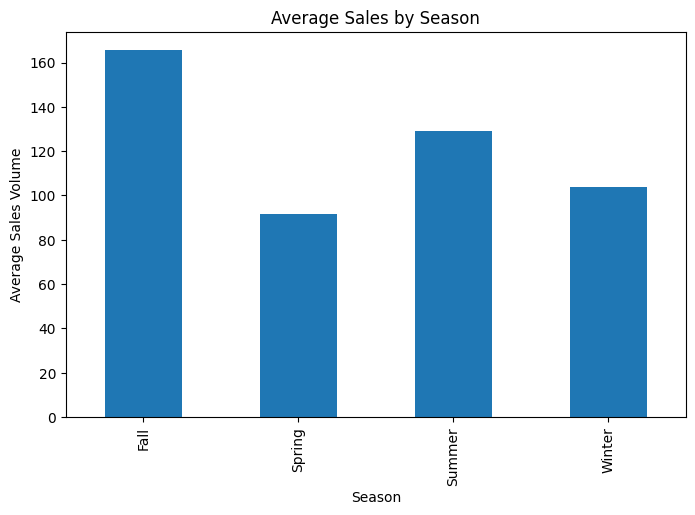

In [18]:
df.groupby('Season')['Sales_Volume'].mean().plot(kind='bar', figsize=(8,5))
plt.title("Average Sales by Season")
plt.ylabel("Average Sales Volume")
plt.show()

## 🌦️ Seasonality Insights

Sales volume varies significantly across seasons, confirming strong seasonal patterns.

### Key Observations:
- **Fall has the highest average sales**
- **Summer follows as the second-highest**
- **Spring records the lowest sales**
- Winter shows moderate performance

### Insight:
This pattern suggests that demand increases during specific periods, possibly due to:
- Product launches
- Holiday shopping cycles
- Consumer spending behavior

### Business Impact:
- Inventory should be increased ahead of Fall and Summer
- Marketing efforts can be intensified during high-demand seasons
- Lower-demand seasons (Spring) may require promotional strategies

In [19]:
df[['Sales_Volume', 'Market_Trend_Index', 'Competitor_Activity_Score', 'Consumer_Confidence_Index']].corr()

,Sales_Volume,Market_Trend_Index,Competitor_Activity_Score,Consumer_Confidence_Index
Sales_Volume,1.000000,-0.001817,-0.001220,-0.001432
Market_Trend_Index,-0.001817,1.000000,-0.002643,-0.001214
Competitor_Activity_Score,-0.001220,-0.002643,1.000000,0.002260
Consumer_Confidence_Index,-0.001432,-0.001214,0.002260,1.000000


## 🔗 Correlation Analysis

The correlation matrix shows that external factors such as:

- Market Trend Index  
- Competitor Activity Score  
- Consumer Confidence Index  

have **very weak linear relationships with Sales Volume**.

### Key Observations:
- Correlation values are close to **zero**
- No strong linear dependency between features and sales

### Insight:
This suggests that:
- Sales patterns may be driven more by **time-based factors (seasonality)** rather than external variables
- Relationships may be **non-linear**, making machine learning models (e.g., Random Forest) potentially more useful than simple linear models

### Implication for Modeling:
- Time series models (ARIMA, Exponential Smoothing) will be critical
- Machine learning models may still capture hidden patterns not visible through correlation

In [20]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

<Axes: xlabel='Month'>

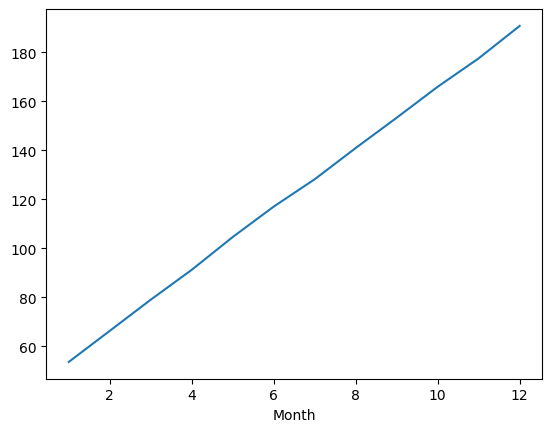

In [21]:
df.groupby('Month')['Sales_Volume'].mean().plot()

## 📅 Monthly Sales Trend Analysis

The monthly analysis of sales volume shows a **steady increase from the beginning to the end of the year**.

### Key Observations:
- Sales are lowest at the start of the year (January)
- Sales gradually increase each month
- Peak sales occur in the final months (November–December)

### Insight:
This indicates a strong **end-of-year demand pattern**, likely driven by:
- Holiday shopping periods
- Promotional campaigns
- Increased consumer spending

### Business Implication:
- Inventory levels should be increased toward the end of the year
- Marketing campaigns can be aligned with high-demand months
- Production planning should anticipate peak demand periods

### Note:
The smooth upward trend suggests a **structured or simulated pattern**, meaning real-world data may show more variability. However, the trend still provides valuable insight for forecasting.

In [22]:
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek

In [23]:
df['Quarter'] = df['Date'].dt.quarter
df['Is_Weekend'] = df['DayOfWeek'].isin([5,6]).astype(int)

## ⚙️ Feature Engineering

Additional time-based features were created to enhance model performance.

### Features Created:

- **Year**: Captures long-term trends
- **Month**: Captures seasonal patterns
- **Day**: Captures intra-month variations
- **DayOfWeek**: Captures weekly patterns
- **Quarter**: Groups months into business quarters
- **Is_Weekend**: Indicates weekend vs weekday behavior

### Purpose:
These features allow machine learning models to better understand:
- Temporal patterns
- Seasonal effects
- Consumer behavior changes over time

In [24]:
df_encoded = pd.get_dummies(df, columns=[
    'Category', 
    'Season', 
    'Product_Specification_1', 
    'Product_Specification_2'
], drop_first=True)

## 🔄 Categorical Encoding

Categorical variables were transformed using **one-hot encoding**.

### Why?

Machine learning models require numerical input, so categorical features must be converted.

### Method Used:
- `pd.get_dummies()` for one-hot encoding
- `drop_first=True` to avoid multicollinearity

### Features Encoded:
- Category
- Season
- Product specifications

This transformation ensures compatibility with machine learning models such as Random Forest.

In [25]:
df_model = df_encoded.drop(columns=['Product_ID', 'Date'])

## 🧹 Feature Selection

Some columns were removed before modeling:

- **Product_ID**: Identifier, no predictive value
- **Date**: Already transformed into multiple time-based features

### Result:
The dataset is now fully numerical and ready for modeling.

In [26]:
X = df_model.drop('Sales_Volume', axis=1)
y = df_model['Sales_Volume']

## 🎯 Feature and Target Split

The dataset is split into:

- **X (features)**: All independent variables
- **y (target)**: Sales_Volume

This separation is necessary for training machine learning models.

In [27]:
split_index = int(len(df_model) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

## ⏳ Train-Test Split (Time-Based)

The dataset is split into training and testing sets using a **time-based split**.

### Why not random split?

Time series data must preserve chronological order to:
- Avoid data leakage
- Simulate real-world forecasting scenarios

### Split:
- 80% training data
- 20% testing dataZ

In [28]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

mae, rmse

(7.289748522339293, np.float64(11.69475864560673))

## ✅ Random Forest Model Results

The Random Forest model produced the following results:

- **MAE:** 7.29
- **RMSE:** 11.69

### Interpretation

The model has a relatively low average prediction error, meaning that on average, its sales volume predictions are approximately **7 units away from the actual values**.

The RMSE value is slightly higher because it penalizes larger errors more strongly.

### Insight

These results suggest that the Random Forest model is performing well and is able to capture patterns in the engineered features, including time-based and categorical variables.

This model will be compared against time series models such as ARIMA and Exponential Smoothing before selecting the final forecasting model.

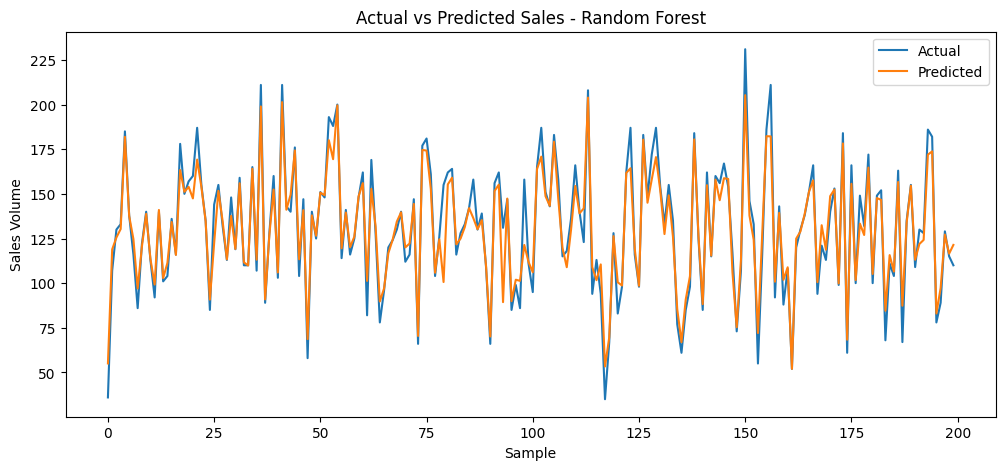

In [30]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:200], label='Actual')
plt.plot(y_pred[:200], label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Sales - Random Forest")
plt.xlabel("Sample")
plt.ylabel("Sales Volume")
plt.show()

## 📊 Model Performance Visualization

The plot above compares the **actual sales values** against the **Random Forest model predictions**.

### Observations

- The predicted values closely follow the actual sales trend
- The model captures **short-term fluctuations** reasonably well
- Some deviations exist during sharp spikes, which is expected in real-world forecasting

### Insight

The Random Forest model demonstrates strong predictive performance and is capable of learning complex patterns from:

- Time-based features (Month, Year, Day)
- Market indicators
- Product characteristics

### Limitation

- The model does not explicitly model time dependencies (unlike ARIMA)
- Performance may degrade for long-term forecasting

### Conclusion

The model is suitable for **short-term demand forecasting**, but will be compared with time-series models to determine the best final approach.